# Derivatives Using SymPy

SymPy is a Python library for **symbolic mathematics**. Unlike NumPy which computes numerical results, SymPy works with exact symbolic expressions — variables, formulas, and algebra.

In this notebook we learn:
1. SymPy basics — symbols, expressions, simplification
2. Computing derivatives with `sympy.diff()`
3. Differentiation rules — sum, product, constant multiple, chain

In [1]:
import sympy
import numpy as np
import matplotlib.pyplot as plt

sympy.init_printing()
x, y = sympy.symbols('x y')
print("Setup complete!")

Setup complete!


In [2]:
def plot_expr(expr, deriv_expr, symbol=x, x_min=-5, x_max=5):
    """Plot a sympy expression and its derivative."""
    f = sympy.lambdify(symbol, expr, 'numpy')
    df = sympy.lambdify(symbol, deriv_expr, 'numpy')
    xs = np.linspace(x_min, x_max, 200)
    
    plt.figure(figsize=(6, 4))
    plt.plot(xs, np.broadcast_to(f(xs), xs.shape), 'r', label=f'f(x) = {expr}')
    plt.plot(xs, np.broadcast_to(df(xs), xs.shape), 'b', label=f"f'(x) = {deriv_expr}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linewidth=0.5)
    plt.tight_layout()
    plt.show()

print("Plotting helper defined!")

Plotting helper defined!


## Section 1: SymPy Basics

SymPy gives **exact** results, not floating-point approximations.

In [3]:
# Exact vs approximate
print(f"Python float: sqrt(18) = {18**0.5}")
print(f"SymPy exact:  sqrt(18) = {sympy.sqrt(18)}")
print(f"SymPy approx: sqrt(18) ≈ {sympy.N(sympy.sqrt(18), 8)}")

Python float: sqrt(18) = 4.242640687119285
SymPy exact:  sqrt(18) = 3*sqrt(2)
SymPy approx: sqrt(18) ≈ 4.2426407


In [4]:
# Symbolic expressions
expr = 2*x**2 - x*y
print("Expression:")
display(expr)

# Expand and factor
new_expr = x * (expr + x*y + x**3)
print("Expanded:")
display(sympy.expand(new_expr))
print("Factored:")
display(sympy.factor(new_expr))

# Substitute values
print("Evaluate 2x² - xy at x=1, y=2:")
display(expr.subs({x: 1, y: 2}))

Expression:


Expanded:


Factored:


Evaluate 2x² - xy at x=1, y=2:


In [5]:
# lambdify() converts symbolic expressions → fast numerical functions
# Use 'numpy' backend for vectorized array operations
x_square = x**2
f = sympy.lambdify(x, x_square, 'numpy')

vals = np.array([1, 2, 3, 4])
print(f"x²  at {vals} = {f(vals)}")

x²  at [1 2 3 4] = [ 1  4  9 16]


## Section 2: Computing Derivatives with `sympy.diff()`

`sympy.diff(expr, x)` returns the symbolic derivative of `expr` with respect to `x`.

f(x) = x**3,  f'(x) = 3*x**2


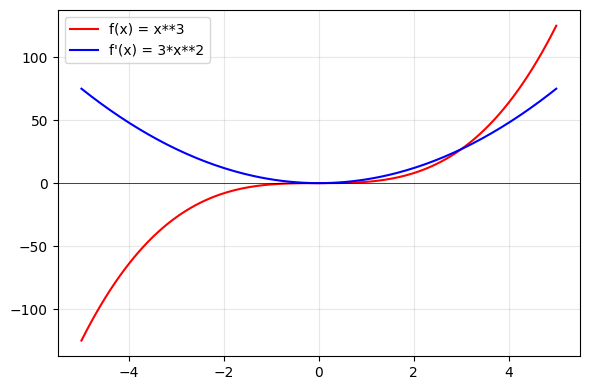

In [6]:
# Derivative of x³
expr = x**3
dfdx = sympy.diff(expr, x)
print(f"f(x) = {expr},  f'(x) = {dfdx}")
plot_expr(expr, dfdx)

d/dx(5) = 0
d/dx(-3) = 0
d/dx(pi) = 0
d/dx(E) = 0


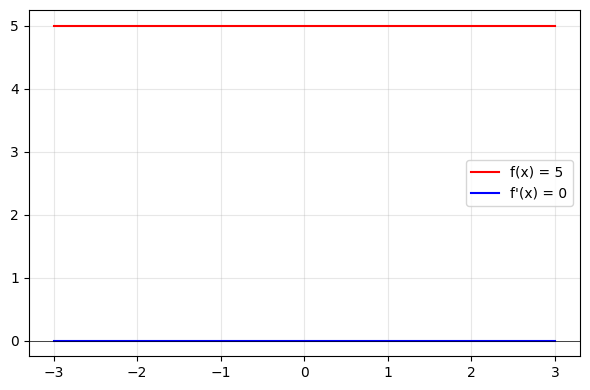

In [7]:
# Derivative of a constant is always 0
for c in [5, -3, sympy.pi, sympy.E]:
    print(f"d/dx({c}) = {sympy.diff(sympy.sympify(c), x)}")

plot_expr(sympy.sympify(5), sympy.diff(sympy.sympify(5), x), x_min=-3, x_max=3)

f(x) = exp(x),  f'(x) = exp(x)


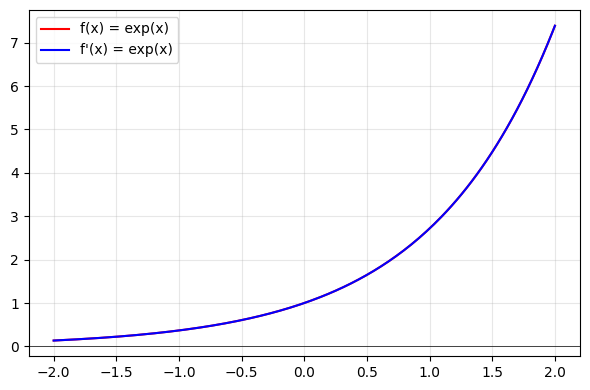

In [8]:
# Derivative of e^x is e^x (self-derivative)
expr = sympy.exp(x)
dfdx = sympy.diff(expr, x)
print(f"f(x) = {expr},  f'(x) = {dfdx}")
plot_expr(expr, dfdx, x_min=-2, x_max=2)

f(x) = log(x),  f'(x) = 1/x


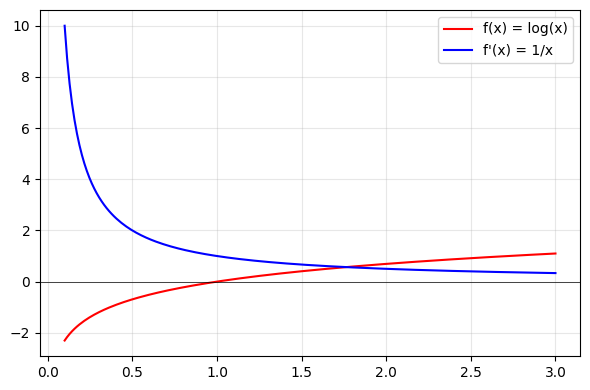

In [9]:
# Derivative of ln(x) is 1/x
expr = sympy.log(x)
dfdx = sympy.diff(expr, x)
print(f"f(x) = {expr},  f'(x) = {dfdx}")
plot_expr(expr, dfdx, x_min=0.1, x_max=3)

f(x) = sin(x),  f'(x) = cos(x)


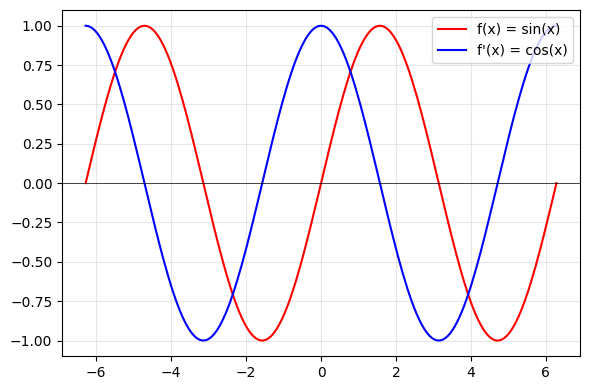

In [10]:
# Derivative of sin(x) = cos(x)
expr = sympy.sin(x)
dfdx = sympy.diff(expr, x)
print(f"f(x) = {expr},  f'(x) = {dfdx}")
plot_expr(expr, dfdx, x_min=-2*float(sympy.pi), x_max=2*float(sympy.pi))

f(x) = cos(x),  f'(x) = -sin(x)


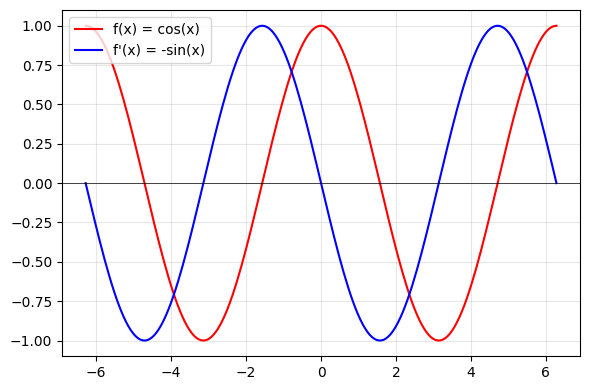

In [11]:
# Derivative of cos(x) = -sin(x)
expr = sympy.cos(x)
dfdx = sympy.diff(expr, x)
print(f"f(x) = {expr},  f'(x) = {dfdx}")
plot_expr(expr, dfdx, x_min=-2*float(sympy.pi), x_max=2*float(sympy.pi))

## Section 3: Differentiation Rules

| Rule | Formula |
|------|---------|
| **Sum** | $\frac{d}{dx}[f + g] = f' + g'$ |
| **Product** | $\frac{d}{dx}[f \cdot g] = f'g + fg'$ |
| **Constant multiple** | $\frac{d}{dx}[c \cdot f] = c \cdot f'$ |
| **Chain** | $\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$ |

In [12]:
# Sum Rule: d/dx[f + g] = f' + g'
f = x**2
g = sympy.sin(x)
h = f + g

print(f"f = {f},  g = {g}")
print(f"d/dx[f + g]   = {sympy.diff(h, x)}")
print(f"f' + g'       = {sympy.diff(f, x) + sympy.diff(g, x)}")
print(f"Match: {sympy.simplify(sympy.diff(h, x) - (sympy.diff(f, x) + sympy.diff(g, x))) == 0}")

f = x**2,  g = sin(x)
d/dx[f + g]   = 2*x + cos(x)
f' + g'       = 2*x + cos(x)
Match: True


In [13]:
# Product Rule: d/dx[f * g] = f'g + fg'
f = x**2
g = sympy.sin(x)
h = f * g

lhs = sympy.diff(h, x)
rhs = sympy.diff(f, x)*g + f*sympy.diff(g, x)

print(f"f = {f},  g = {g}")
print(f"d/dx[f * g]       = {lhs}")
print(f"f'g + fg'         = {sympy.expand(rhs)}")
print(f"Match: {sympy.simplify(lhs - rhs) == 0}")

f = x**2,  g = sin(x)
d/dx[f * g]       = x**2*cos(x) + 2*x*sin(x)
f'g + fg'         = x**2*cos(x) + 2*x*sin(x)
Match: True


In [14]:
# Constant Multiple Rule: d/dx[c * f] = c * f'
c = 5
f = x**3

print(f"c = {c},  f = {f}")
print(f"d/dx[{c} * {f}] = {sympy.diff(c * f, x)}")
print(f"c * f'           = {c * sympy.diff(f, x)}")
print(f"Match: {sympy.simplify(sympy.diff(c * f, x) - c * sympy.diff(f, x)) == 0}")

c = 5,  f = x**3
d/dx[5 * x**3] = 15*x**2
c * f'           = 15*x**2
Match: True


In [15]:
# Chain Rule: d/dx[f(g(x))] = f'(g(x)) * g'(x)
u = sympy.Symbol('u')

# Example 1: (x² + 1)³
g_inner = x**2 + 1
f_outer = u**3
composite = g_inner**3

lhs = sympy.diff(composite, x)
rhs = sympy.diff(f_outer, u).subs(u, g_inner) * sympy.diff(g_inner, x)

print(f"f(g(x)) = {composite}")
print(f"d/dx[f(g(x))] = {lhs}")
print(f"f'(g(x))*g'(x) = {sympy.expand(rhs)}")
print(f"Match: {sympy.simplify(lhs - rhs) == 0}")

# Example 2: sin(x²)
print()
composite2 = sympy.sin(x**2)
lhs2 = sympy.diff(composite2, x)
rhs2 = sympy.diff(sympy.sin(u), u).subs(u, x**2) * sympy.diff(x**2, x)

print(f"f(g(x)) = {composite2}")
print(f"d/dx[f(g(x))] = {lhs2}")
print(f"f'(g(x))*g'(x) = {rhs2}")
print(f"Match: {sympy.simplify(lhs2 - rhs2) == 0}")

f(g(x)) = (x**2 + 1)**3
d/dx[f(g(x))] = 6*x*(x**2 + 1)**2
f'(g(x))*g'(x) = 6*x**5 + 12*x**3 + 6*x
Match: True

f(g(x)) = sin(x**2)
d/dx[f(g(x))] = 2*x*cos(x**2)
f'(g(x))*g'(x) = 2*x*cos(x**2)
Match: True
